In [1]:
from frumkin.electrolyte import LatticeElectrolyte, Ion, Water
from frumkin.gongadze_iglic import GongadzeIglic

concentration = 1e-3
results = []

el = LatticeElectrolyte([
    Water(name='water'),
    Ion(r"sodium", 6, concentration, +1),
    Ion(r"chlorine", 2, concentration, -1),
])

model = GongadzeIglic(el, ohp=3)

Sweep from -3.89e+01 to 3.89e+01, starting at 0.00e+00. Maximum relative residual: 8.312e-07.


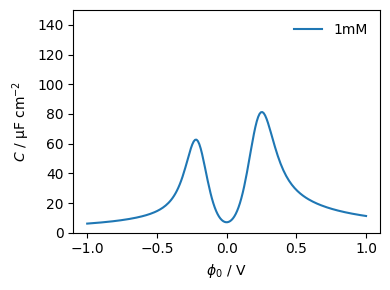

In [2]:
import matplotlib.pyplot as plt
import numpy as np

potential = np.linspace(-1, 1, 200)
result = model.voltammetry(potential, tol=1e-5)

fig, ax = plt.subplots(figsize=(4,3))
ax.plot(result.potential, result.capacitance, label=f"{concentration*1e3:.0f}mM")
ax.set_ylim([0, 150])
ax.legend(frameon=False)
ax.set_xlabel(r'$\phi_0$ / V')
ax.set_ylabel(r'$C$ / μF cm$^{-2}$')
fig.tight_layout()
fig.savefig('result1.png', dpi=120)

Sweep from 0.00e+00 to -3.89e+01, starting at 0.00e+00. Maximum relative residual: 8.311e-07.


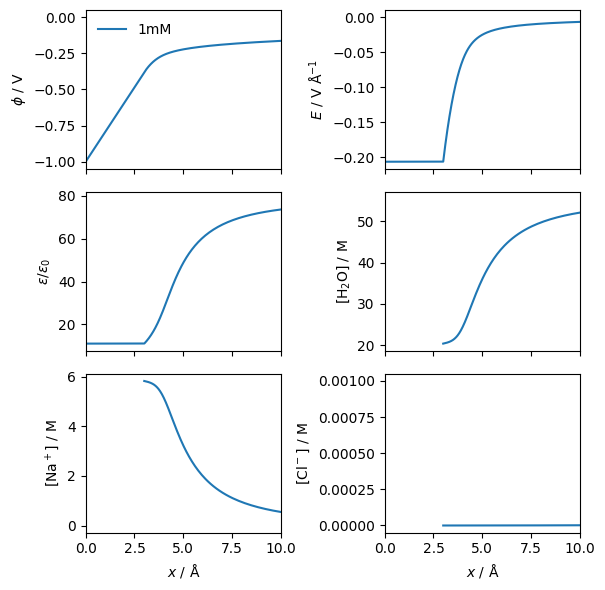

In [3]:
potential = -1  # V vs. PZC
prf = model.single_point(potential, tol=1e-5)

fig, ax = plt.subplots(figsize=(6,6), nrows=3, ncols=2, sharex=True)

ax[0, 0].plot(prf.x, prf.potential, label=f"{concentration*1e3:.0f}mM")
ax[0, 1].plot(prf.x, prf.electric_field)
ax[1, 0].plot(prf.x, prf.permittivity)
ax[1, 1].plot(prf.x, prf.concentrations['water'])
ax[2, 0].plot(prf.x, prf.concentrations['sodium'])
ax[2, 1].plot(prf.x, prf.concentrations['chlorine'])

ax[2, 0].set_xlabel(r'$x$ / Å')
ax[2, 1].set_xlabel(r'$x$ / Å')
ax[0, 0].set_ylabel(r'$\phi$ / V')
ax[0, 1].set_ylabel(r'$E$ / V $\mathrm{\AA}^{-1}$')
ax[1, 0].set_ylabel(r'$\varepsilon/\varepsilon_0$')
ax[1, 1].set_ylabel(r'[H$_2$O] / M')
ax[2, 0].set_ylabel(r'[Na$^+$] / M')
ax[2, 1].set_ylabel(r'[Cl$^-$] / M')
ax[0, 0].set_xlim([0, 10])
ax[0, 0].legend(frameon=False)
fig.tight_layout()
fig.savefig('result2.png')